In [2]:
import os
import re
import zipfile

import folium
import kmedoids
import mcr_py.utils.geometa
import mcr_py.utils.h3
import polars as pl
import polars_h3 as plh3
import polars_xdt as xdt
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import MinMaxScaler

In [2]:
# parameters
city_name = "cologne"
mode = "nextbike"
bike_file = f"{mode}_availability_{city_name.lower()}.csv"
bike_zip_file = f"../data/sharing_locations_raw/{bike_file}.zip"
geometa_path = f"../data/20250110/cache/{city_name.lower()}_geometa.pkl"
sharing_positions_path = f"../data/sharing_locations_clustered/{city_name.lower()}_{mode}"
# city_center = [52.5170365, 13.3888599]
city_center = [50.938361, 6.959974]

In [3]:
with zipfile.ZipFile(bike_zip_file).open(bike_file) as f:
    availabilities = pl.read_csv(f)

availabilities = availabilities.rename(lambda name: name.replace(f"{mode}_availability_", ""))
availabilities = availabilities.with_columns(
    pl.col("geometry").alias("geometry_str"),
    pl.col("geometry")
    .str.replace(r"[a-zA-Z\(]+", "")
    .str.replace(r"\)", "")
    .str.split(by=" ")
    .list.to_struct(fields=["lon", "lat"], n_field_strategy="max_width"),
).unnest("geometry")
availabilities = availabilities.with_columns(
    pl.col("lon").cast(pl.Float64),
    pl.col("lat").cast(pl.Float64),
    availabilities["valid_from"].str.to_datetime(),
    availabilities["valid_till"].str.to_datetime(),
)
availabilities = availabilities.with_columns(
    plh3.latlng_to_cell("lat", "lon", resolution=8, return_dtype=pl.Utf8).alias("h3_cell"),
    xdt.ceil("valid_from", "1h"),
    pl.col("valid_till").dt.truncate("1h"),
)

## Spatial and Temporal Discretization 

In [4]:
availabilities = availabilities.filter(pl.col("valid_from") <= pl.col("valid_till"))

In [ ]:
availabilities = availabilities.with_columns(
    pl.struct("valid_from", "valid_till")
    .map_elements(
        lambda row: pl.datetime_range(
            row["valid_from"], row["valid_till"], "1h", closed="both", eager=True
        ),
        return_dtype=pl.List(pl.Datetime),
    )
    .alias("interval")
)

In [ ]:
bikes_per_hex_per_time = (
    availabilities.explode("interval").group_by(["h3_cell", "interval"]).len()
)

bikes_per_hex_per_time.write_parquet(
    f"../data/sharing_locations_raw/{mode}_availability_{city_name.lower()}_bucketed.parquet"
)

In [5]:
bikes_per_hex_per_time = pl.read_parquet(
    f"../data/sharing_locations_raw/{mode}_availability_{city_name.lower()}_bucketed.parquet"
)

In [6]:
pivot_hex_time = bikes_per_hex_per_time.pivot(
    index="interval", on="h3_cell", values="len"
).fill_null(0)

In [7]:
scaler = MinMaxScaler()
scaled_bikes = scaler.fit_transform(pivot_hex_time)

In [8]:
# distmatrix = pairwise_distances(scaled_bikes, None, metric='mahalanobis')

In [9]:
distmatrix_euclidean = pairwise_distances(scaled_bikes, None, metric="euclidean")

In [10]:
stats = []
for k in range(2, 15):
    model = kmedoids.KMedoids(n_clusters=k, method="fasterpam", random_state=4711)
    pred_ = model.fit_predict(distmatrix_euclidean)
    stats.append(
        {
            "k": k,
            "calinski_harabasz_score": calinski_harabasz_score(pivot_hex_time, pred_),
        }
    )

<Axes: xlabel='k'>

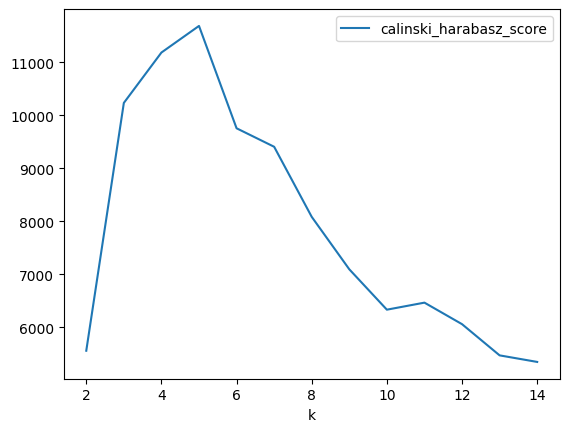

In [11]:
pd.DataFrame(stats).plot(x="k", y="calinski_harabasz_score")
# plt.savefig(f"../figures/sharing_clustering/{city_name}_{mode}_calinski_harabasz.png")

In [12]:
# Number of clusters you want
n_clusters = 5

model = kmedoids.KMedoids(n_clusters=n_clusters, method="fasterpam", random_state=4711)
pred = model.fit_predict(distmatrix_euclidean)

In [13]:
pivot_hex_time = pivot_hex_time.with_columns(pred=pred)

In [14]:
rows = [pivot_hex_time.row(idx) for idx in model.medoid_indices_]
df = pd.DataFrame(rows, columns=pivot_hex_time.columns)
df = df.drop(columns="pred")
df = df.set_index("interval")

In [ ]:
geo_meta = mcr_py.geometa.GeoMeta.load(geometa_path)

m = folium.Map(location=city_center, zoom_start=12)
geo_meta.add_to_folium_map(m)
mcr_py.h3.plot_h3_cells_on_folium(df.iloc[0].to_dict(), m, popup_callback=lambda x, _: x)
m

In [16]:
availabilities

vehicle_id,lon,lat,valid_from,valid_till,geometry_str,h3_cell
i64,f64,f64,datetime[μs],datetime[μs],str,str
7475,6.951297,50.969173,2024-04-01 01:00:00,2024-04-01 05:00:00,"""POINT(6.951296806335449 50.969…","""881fa198e5fffff"""
8371,7.052882,50.875942,2024-04-01 01:00:00,2024-04-19 07:00:00,"""POINT(7.052882194519043 50.875…","""881fa18803fffff"""
28379,6.947264,50.931862,2024-04-01 01:00:00,2024-04-01 05:00:00,"""POINT(6.947264194488525 50.931…","""881fa199b9fffff"""
28381,6.904973,50.969929,2024-04-01 01:00:00,2024-04-01 05:00:00,"""POINT(6.904973030090332 50.969…","""881fa19823fffff"""
28385,6.958505,50.944424,2024-04-01 01:00:00,2024-04-01 02:00:00,"""POINT(6.958505153656006 50.944…","""881fa1999dfffff"""
…,…,…,…,…,…,…
28418,7.0148,50.967449,2024-03-27 17:00:00,2024-03-27 20:00:00,"""POINT(7.014800071716309 50.967…","""881fa198b1fffff"""
28418,7.017212,50.969433,2024-03-27 22:00:00,2024-03-27 22:00:00,"""POINT(7.0172119140625 50.96943…","""881fa198bbfffff"""
28418,7.007743,50.951645,2024-03-27 23:00:00,2024-03-28 01:00:00,"""POINT(7.007742881774902 50.951…","""881fa18a4bfffff"""


In [22]:
def get_locations_at_time(df: pl.DataFrame, timestamp) -> pl.DataFrame:
    filtered = df.filter(
        (pl.col("valid_from") <= timestamp) & (pl.col("valid_till") >= timestamp)
    )
    return filtered.select(pl.col("lat"), pl.col("lon"))

In [ ]:
# center in cologne
m = folium.Map(location=city_center, zoom_start=13)

colors = ["red", "blue", "green", "yellow", "purple", "orange", "brown"]

for i, time in enumerate(df.index):
    locations_at_time = get_locations_at_time(availabilities, time)
    for point in locations_at_time.iter_rows():
        folium.CircleMarker(
            location=point, radius=2, color=colors[i], fill=True, fill_color="#000000"
        ).add_to(m)


m

In [24]:
def derive_filename(s) -> str:
    s = re.sub(r"[^a-zA-Z0-9\-_.]", "_", str(s))
    s = s.replace(" ", "_")
    s = re.sub(r"_+", "_", s)
    return s

In [27]:
os.makedirs(sharing_positions_path, exist_ok=True)
for time in df.index:
    locations_at_time = get_locations_at_time(availabilities, time)
    filename = derive_filename(time) + ".csv"
    file_path = os.path.join(sharing_positions_path, filename)
    locations_at_time.write_csv(file_path)